# Pattern Recognition Techniques Applied to Weather Forecasting
**Dataset:** Bureau of Meteorology — 145,460 daily records across 49 Australian locations.
**Goal:** Predict whether it will rain tomorrow using K-Means clustering, Logistic Regression, SVM, Random Forest, and Gradient Boosting.

---

## Setup
All required libraries are imported here.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.cluster          import KMeans
from sklearn.preprocessing    import StandardScaler, LabelEncoder
from sklearn.impute            import SimpleImputer
from sklearn.model_selection  import train_test_split
from sklearn.base             import clone
from sklearn.linear_model     import LogisticRegression
from sklearn.svm              import LinearSVC
from sklearn.calibration      import CalibratedClassifierCV
from sklearn.ensemble         import RandomForestClassifier, GradientBoostingClassifier
from imblearn.over_sampling   import SMOTE
from imblearn.pipeline        import Pipeline as ImbPipeline
from sklearn.model_selection  import train_test_split, RandomizedSearchCV, StratifiedKFold
from scipy.stats              import loguniform, randint, uniform
from sklearn.metrics          import (accuracy_score, precision_score, recall_score,
                                       f1_score, roc_auc_score,
                                       classification_report, confusion_matrix)

print("All libraries loaded successfully")

All libraries loaded successfully


In [2]:
# Set the path to your weatherAUS_2.csv file
# If the file is in the same folder as this notebook, just use the filename.
# Otherwise paste the full path, for example:
#   DATA_PATH = r"C:\Users\YourName\Desktop\weatherAUS_2.csv"
DATA_PATH = "weatherAUS_2.csv"

df_raw = pd.read_csv(DATA_PATH)
print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Columns: {df_raw.columns.tolist()}")
print(f"Missing values (%):{(df_raw.isnull().mean()*100).round(1).to_string()}")

Shape: 145,460 rows × 23 columns
Columns: ['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow']
Missing values (%):Date              0.0
Location          0.0
MinTemp           1.0
MaxTemp           0.9
Rainfall          2.2
Evaporation      43.2
Sunshine         48.0
WindGustDir       7.1
WindGustSpeed     7.1
WindDir9am        7.3
WindDir3pm        2.9
WindSpeed9am      1.2
WindSpeed3pm      2.1
Humidity9am       1.8
Humidity3pm       3.1
Pressure9am      10.4
Pressure3pm      10.3
Cloud9am         38.4
Cloud3pm         40.8
Temp9am           1.2
Temp3pm           2.5
RainToday         2.2
RainTomorrow      2.2


## Data Preprocessing
The raw dataset is cleaned by removing columns that cause data leakage, filling missing values, encoding categorical features, and scaling all numbers to the same range so no single feature dominates the models.

In [3]:
df = df_raw.copy()

# Extract Month from Date
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Month"] = df["Date"].dt.month
df = df.drop(columns=["Date"])

# Drop leakage + high-missing columns
DROP_COLS = ["Rainfall", "RainToday", "Evaporation", "Sunshine", "Cloud9am", "Cloud3pm"]
df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

# Drop NaN targets, encode Yes→1 / No→0
df = df[df["RainTomorrow"].notna()].copy()
le = LabelEncoder()
df["Target"] = le.fit_transform(df["RainTomorrow"].astype(str))
df = df.drop(columns=["RainTomorrow"])

# Auto-detect feature columns
EXCLUDE = {"Location", "Target"}
NUMERIC_COLS     = [c for c in df.select_dtypes(include="number").columns if c not in EXCLUDE]
CATEGORICAL_COLS = [c for c in df.select_dtypes(include=["object"]).columns if c not in EXCLUDE]

# Impute
num_imputer = SimpleImputer(strategy="median")
df[NUMERIC_COLS] = num_imputer.fit_transform(df[NUMERIC_COLS])
cat_imputer = SimpleImputer(strategy="most_frequent")
df[CATEGORICAL_COLS] = cat_imputer.fit_transform(df[CATEGORICAL_COLS])

# One-hot encode
df_model = pd.get_dummies(df, columns=CATEGORICAL_COLS, drop_first=False)
ohe_cols = [c for c in df_model.columns if any(c.startswith(cat+"_") for cat in CATEGORICAL_COLS)]

# Scale
scaler = StandardScaler()
df_model[NUMERIC_COLS] = scaler.fit_transform(df_model[NUMERIC_COLS])

FEATURE_COLS = NUMERIC_COLS + ohe_cols

# Class imbalance report
counts = df_model["Target"].value_counts()
print(f"Features: {len(FEATURE_COLS)}")
print(f"Class imbalance: {counts[0]/counts[1]:.1f}:1  (No Rain : Rain)")
print(f"Baseline accuracy (always predict No): {counts[0]/len(df_model):.1%}")
print(f"Total rows: {len(df_model):,}")

Features: 60
Class imbalance: 3.5:1  (No Rain : Rain)
Baseline accuracy (always predict No): 77.6%
Total rows: 142,193


## K-Means Clustering
Instead of manually grouping locations, the data decides which Australian cities share similar climates — separate models are then trained per group so each one specialises in its own weather patterns.

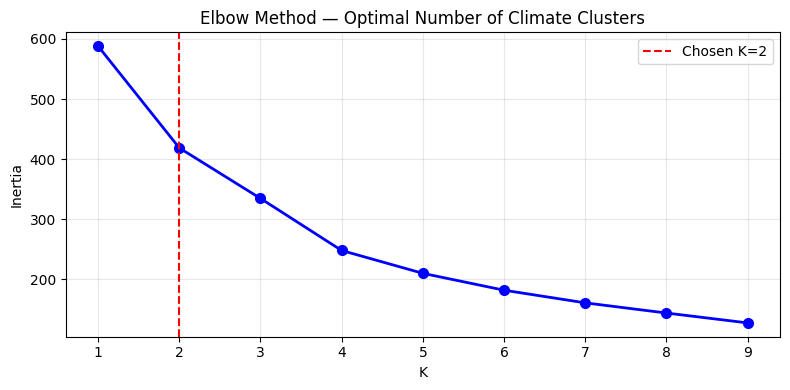

Location → Cluster assignment:
  Adelaide               → Cluster 1
  Albany                 → Cluster 1
  Albury                 → Cluster 1
  AliceSprings           → Cluster 0
  BadgerysCreek          → Cluster 1
  Ballarat               → Cluster 1
  Bendigo                → Cluster 1
  Brisbane               → Cluster 1
  Cairns                 → Cluster 0
  Canberra               → Cluster 1
  Cobar                  → Cluster 1
  CoffsHarbour           → Cluster 1
  Dartmoor               → Cluster 1
  Darwin                 → Cluster 0
  GoldCoast              → Cluster 1
  Hobart                 → Cluster 1
  Katherine              → Cluster 0
  Launceston             → Cluster 1
  Melbourne              → Cluster 1
  MelbourneAirport       → Cluster 1
  Mildura                → Cluster 1
  Moree                  → Cluster 1
  MountGambier           → Cluster 1
  MountGinini            → Cluster 1
  Newcastle              → Cluster 1
  Nhil                   → Cluster 1
  Norah

In [5]:
# Per-location climate profiles
location_stats = df_model.groupby(df["Location"])[NUMERIC_COLS].mean().reset_index()

loc_scaler = StandardScaler()
loc_matrix = loc_scaler.fit_transform(location_stats[NUMERIC_COLS])

# Elbow method
inertias = []
k_range  = range(1, min(10, len(location_stats)))
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    inertias.append(km.fit(loc_matrix).inertia_)

diffs2    = np.diff(np.diff(inertias))
N_CLUSTERS = max(2, min(int(np.argmax(diffs2))+2, min(5, len(location_stats)-1)))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(k_range), inertias, "bo-", linewidth=2, markersize=7)
ax.axvline(x=N_CLUSTERS, color="red", linestyle="--", label=f"Chosen K={N_CLUSTERS}")
ax.set_xlabel("K"); ax.set_ylabel("Inertia")
ax.set_title("Elbow Method — Optimal Number of Climate Clusters")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

km_final = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
location_stats["Cluster"] = km_final.fit_predict(loc_matrix)
loc_to_cluster = dict(zip(location_stats["Location"], location_stats["Cluster"]))
df_model["Cluster"] = df["Location"].map(loc_to_cluster)

print("Location → Cluster assignment:")
for _, r in location_stats[["Location","Cluster"]].iterrows():
    print(f"  {r['Location']:<22} → Cluster {r['Cluster']}")

## Train / Test Split
20% of the data is held out as a test set the models never see during training, with the same Rain/No-Rain ratio preserved in both halves.

In [6]:
X        = df_model[FEATURE_COLS].values
y        = df_model["Target"].values
clusters = df_model["Cluster"].values

X_train, X_test, y_train, y_test, c_train, c_test = train_test_split(
    X, y, clusters, test_size=0.2, stratify=y, random_state=42)

print(f"Train: {len(X_train):,} samples  (Rain rate: {y_train.mean():.1%})")
print(f"Test : {len(X_test):,}  samples  (Rain rate: {y_test.mean():.1%})")

Train: 113,754 samples  (Rain rate: 22.4%)
Test : 28,439  samples  (Rain rate: 22.4%)


In [7]:
def evaluate(y_true, y_pred, y_prob=None):
    """Return metrics dict and print classification report."""
    acc  = accuracy_score (y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score   (y_true, y_pred, zero_division=0)
    f1   = f1_score       (y_true, y_pred, zero_division=0)
    auc  = roc_auc_score  (y_true, y_prob) if y_prob is not None else float("nan")
    print(f"  Accuracy : {acc:.3f}")
    print(f"  Precision: {prec:.3f}  (of all Rain predictions, how many were correct?)")
    print(f"  Recall   : {rec:.3f}  (of all actual Rain days, how many did we catch?)")
    print(f"  F1-Score : {f1:.3f}  (harmonic mean of Precision and Recall)")
    print(f"  AUC-ROC  : {auc:.3f}  (how well model ranks Rain > No Rain)")
    return {"Accuracy":acc,"Precision":prec,"Recall":rec,"F1":f1,"AUC":auc}

all_model_results = {}  # stores results for final comparison

---
## Section 2.1 — Logistic Regression
Logistic Regression draws a straight-line boundary through the feature space and assigns a probability to each day being rainy. It is the simplest classifier here and acts as the baseline everything else is compared against.

In [8]:
print("=" * 60)
print("  2.1 — Logistic Regression (per climate cluster)")
print("=" * 60)

lr_results = []
lr_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)

for cid in sorted(np.unique(clusters)):
    X_tr_c = X_train[c_train==cid];  y_tr_c = y_train[c_train==cid]
    X_te_c = X_test [c_test ==cid];  y_te_c = y_test [c_test ==cid]
    if len(X_tr_c) < 10 or len(np.unique(y_tr_c)) < 2: continue
    sm = SMOTE(random_state=42, k_neighbors=min(5,sum(y_tr_c==1)-1))
    Xb, yb = sm.fit_resample(X_tr_c, y_tr_c)
    m = clone(lr_model); m.fit(Xb, yb)
    yp = m.predict(X_te_c)
    ypr = m.predict_proba(X_te_c)[:,1]
    print(f"Cluster {cid} ({len(X_te_c):,} test samples):")
    r = evaluate(y_te_c, yp, ypr)
    r["Cluster"] = cid; lr_results.append(r)

lr_avg = pd.DataFrame(lr_results).mean(numeric_only=True)
print(f"Macro-average across clusters:")
print(f"  F1={lr_avg['F1']:.3f}  AUC={lr_avg['AUC']:.3f}")
all_model_results["Logistic Regression"] = dict(lr_avg)

  2.1 — Logistic Regression (per climate cluster)
Cluster 0 (3,021 test samples):
  Accuracy : 0.837
  Precision: 0.558  (of all Rain predictions, how many were correct?)
  Recall   : 0.854  (of all actual Rain days, how many did we catch?)
  F1-Score : 0.675  (harmonic mean of Precision and Recall)
  AUC-ROC  : 0.914  (how well model ranks Rain > No Rain)
Cluster 1 (25,418 test samples):
  Accuracy : 0.774
  Precision: 0.502  (of all Rain predictions, how many were correct?)
  Recall   : 0.753  (of all actual Rain days, how many did we catch?)
  F1-Score : 0.602  (harmonic mean of Precision and Recall)
  AUC-ROC  : 0.849  (how well model ranks Rain > No Rain)
Macro-average across clusters:
  F1=0.639  AUC=0.881


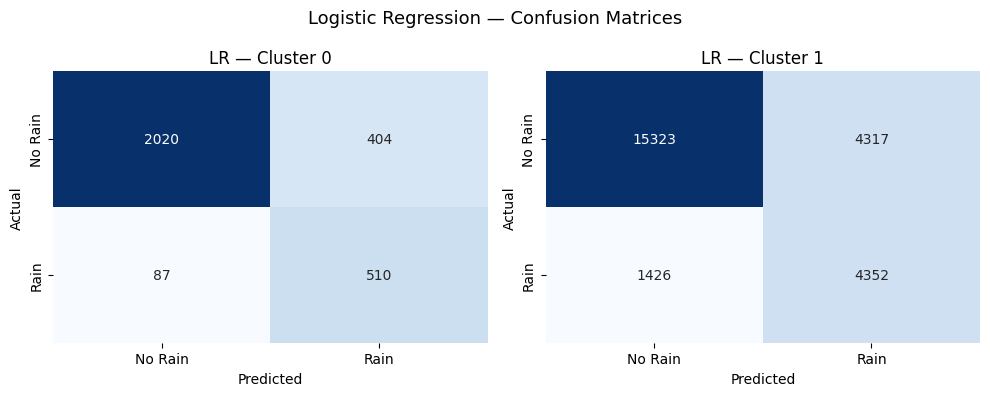

In [9]:
# Confusion matrix for LR
fig, axes = plt.subplots(1, N_CLUSTERS, figsize=(5*N_CLUSTERS, 4))
if N_CLUSTERS == 1: axes = [axes]
for cid in sorted(np.unique(clusters)):
    X_tr_c = X_train[c_train==cid]; y_tr_c = y_train[c_train==cid]
    X_te_c = X_test [c_test ==cid]; y_te_c = y_test [c_test ==cid]
    if len(X_tr_c) < 10 or len(np.unique(y_tr_c)) < 2: continue
    sm = SMOTE(random_state=42, k_neighbors=min(5,sum(y_tr_c==1)-1))
    Xb, yb = sm.fit_resample(X_tr_c, y_tr_c)
    m = clone(lr_model); m.fit(Xb, yb)
    cm = confusion_matrix(y_te_c, m.predict(X_te_c))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No Rain","Rain"], yticklabels=["No Rain","Rain"],
                ax=axes[cid], cbar=False)
    axes[cid].set_title(f"LR — Cluster {cid}")
    axes[cid].set_xlabel("Predicted"); axes[cid].set_ylabel("Actual")
plt.suptitle("Logistic Regression — Confusion Matrices", fontsize=13)
plt.tight_layout(); plt.show()

---
## Section 2.2 — Random Forest
Random Forest builds 100 decision trees, each trained on a slightly different random slice of the data, then takes a majority vote — this averaging process cancels out individual tree mistakes and picks up non-linear weather patterns that a straight line cannot.

  2.2 — Random Forest (full dataset + cluster feature)
SMOTE: 113,754 → 176,504 training samples
Random Forest results:
  Accuracy : 0.793
  Precision: 0.527  (of all Rain predictions, how many were correct?)
  Recall   : 0.730  (of all actual Rain days, how many did we catch?)
  F1-Score : 0.612  (harmonic mean of Precision and Recall)
  AUC-ROC  : 0.851  (how well model ranks Rain > No Rain)


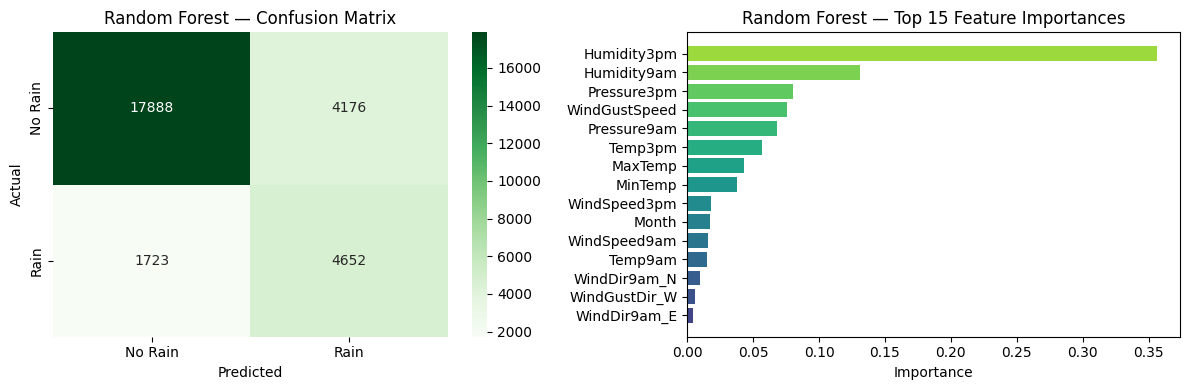

In [10]:
print("=" * 60)
print("  2.2 — Random Forest (full dataset + cluster feature)")
print("=" * 60)

X_ens     = np.column_stack([X, clusters])
Xtr_e, Xte_e, ytr_e, yte_e = train_test_split(
    X_ens, y, test_size=0.2, stratify=y, random_state=42)

sm_ens = SMOTE(random_state=42)
Xtr_bal, ytr_bal = sm_ens.fit_resample(Xtr_e, ytr_e)
print(f"SMOTE: {len(ytr_e):,} → {len(ytr_bal):,} training samples")

rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=8, min_samples_leaf=4,
    class_weight="balanced", random_state=42, n_jobs=-1)
rf_model.fit(Xtr_bal, ytr_bal)

rf_pred  = rf_model.predict(Xte_e)
rf_prob  = rf_model.predict_proba(Xte_e)[:,1]
print("Random Forest results:")
rf_r = evaluate(yte_e, rf_pred, rf_prob)
all_model_results["Random Forest"] = rf_r

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cm = confusion_matrix(yte_e, rf_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No Rain","Rain"], yticklabels=["No Rain","Rain"], ax=axes[0])
axes[0].set_title("Random Forest — Confusion Matrix")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

# Feature importances (top 15)
imp  = rf_model.feature_importances_
feat = FEATURE_COLS + ["Cluster"]
idx  = np.argsort(imp)[::-1][:15]
axes[1].barh([feat[i] for i in idx][::-1], imp[idx][::-1],
             color=plt.cm.viridis(np.linspace(0.2,0.85,15)))
axes[1].set_title("Random Forest — Top 15 Feature Importances")
axes[1].set_xlabel("Importance")
plt.tight_layout(); plt.show()

---
## Section 2.3 — Support Vector Machine
SVM finds the boundary that sits as far away as possible from both classes, maximising the gap between rainy and dry days in feature space. LinearSVC is used here because the full RBF version would take hours on 145k rows.

In [11]:
print("=" * 60)
print("  2.3 — SVM Linear (per climate cluster)")
print("=" * 60)

svm_results = []
svm_proto   = CalibratedClassifierCV(
    LinearSVC(class_weight="balanced", max_iter=2000, random_state=42), cv=3)

for cid in sorted(np.unique(clusters)):
    X_tr_c = X_train[c_train==cid];  y_tr_c = y_train[c_train==cid]
    X_te_c = X_test [c_test ==cid];  y_te_c = y_test [c_test ==cid]
    if len(X_tr_c) < 10 or len(np.unique(y_tr_c)) < 2: continue
    sm = SMOTE(random_state=42, k_neighbors=min(5,sum(y_tr_c==1)-1))
    Xb, yb = sm.fit_resample(X_tr_c, y_tr_c)
    m = clone(svm_proto); m.fit(Xb, yb)
    yp = m.predict(X_te_c)
    ypr = m.predict_proba(X_te_c)[:,1]
    print(f"Cluster {cid} ({len(X_te_c):,} test samples):")
    r = evaluate(y_te_c, yp, ypr)
    r["Cluster"] = cid; svm_results.append(r)

svm_avg = pd.DataFrame(svm_results).mean(numeric_only=True)
print(f"Macro-average across clusters:")
print(f"  F1={svm_avg['F1']:.3f}  AUC={svm_avg['AUC']:.3f}")
all_model_results["SVM (Linear)"] = dict(svm_avg)

  2.3 — SVM Linear (per climate cluster)
Cluster 0 (3,021 test samples):
  Accuracy : 0.835
  Precision: 0.553  (of all Rain predictions, how many were correct?)
  Recall   : 0.851  (of all actual Rain days, how many did we catch?)
  F1-Score : 0.671  (harmonic mean of Precision and Recall)
  AUC-ROC  : 0.914  (how well model ranks Rain > No Rain)
Cluster 1 (25,418 test samples):
  Accuracy : 0.774
  Precision: 0.502  (of all Rain predictions, how many were correct?)
  Recall   : 0.754  (of all actual Rain days, how many did we catch?)
  F1-Score : 0.603  (harmonic mean of Precision and Recall)
  AUC-ROC  : 0.848  (how well model ranks Rain > No Rain)
Macro-average across clusters:
  F1=0.637  AUC=0.881


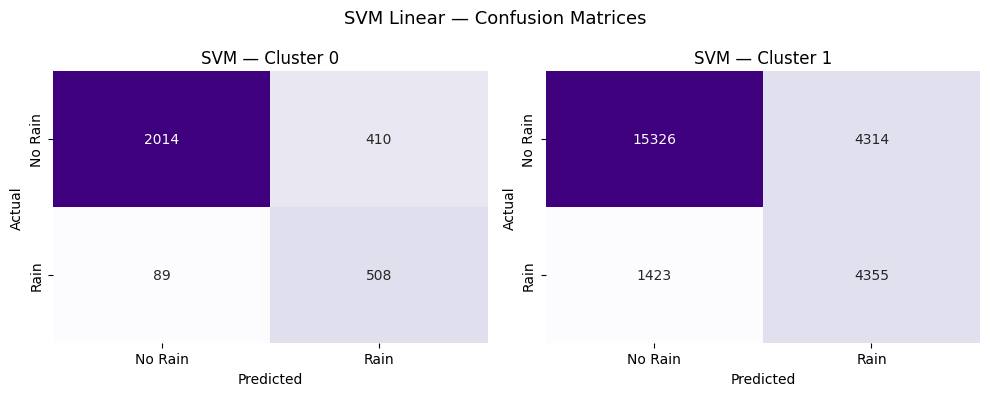

In [12]:
# Confusion matrix for SVM
fig, axes = plt.subplots(1, N_CLUSTERS, figsize=(5*N_CLUSTERS, 4))
if N_CLUSTERS == 1: axes = [axes]
for cid in sorted(np.unique(clusters)):
    X_tr_c = X_train[c_train==cid]; y_tr_c = y_train[c_train==cid]
    X_te_c = X_test [c_test ==cid]; y_te_c = y_test [c_test ==cid]
    if len(X_tr_c) < 10 or len(np.unique(y_tr_c)) < 2: continue
    sm = SMOTE(random_state=42, k_neighbors=min(5,sum(y_tr_c==1)-1))
    Xb, yb = sm.fit_resample(X_tr_c, y_tr_c)
    m = clone(svm_proto); m.fit(Xb, yb)
    cm = confusion_matrix(y_te_c, m.predict(X_te_c))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
                xticklabels=["No Rain","Rain"], yticklabels=["No Rain","Rain"],
                ax=axes[cid], cbar=False)
    axes[cid].set_title(f"SVM — Cluster {cid}")
    axes[cid].set_xlabel("Predicted"); axes[cid].set_ylabel("Actual")
plt.suptitle("SVM Linear — Confusion Matrices", fontsize=13)
plt.tight_layout(); plt.show()

---
## Section 2.4 — Gradient Boosting
Gradient Boosting builds trees one after another, where each new tree focuses specifically on correcting the mistakes the previous ones made — a sequential process that progressively reduces errors the other models leave behind.

  2.4 — Gradient Boosting (full dataset + cluster feature)
Gradient Boosting results:
  Accuracy : 0.800
  Precision: 0.541  (of all Rain predictions, how many were correct?)
  Recall   : 0.714  (of all actual Rain days, how many did we catch?)
  F1-Score : 0.615  (harmonic mean of Precision and Recall)
  AUC-ROC  : 0.854  (how well model ranks Rain > No Rain)


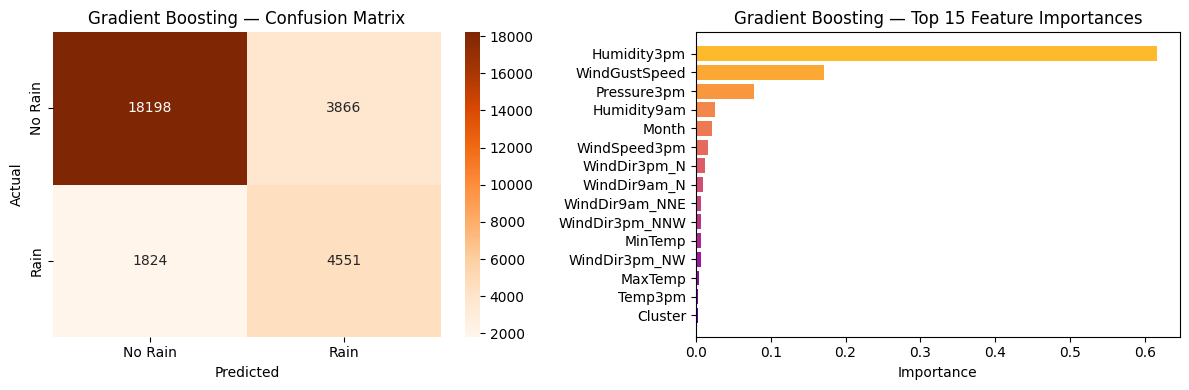

In [13]:
print("=" * 60)
print("  2.4 — Gradient Boosting (full dataset + cluster feature)")
print("=" * 60)

gb_model = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.05,
    max_depth=3, min_samples_leaf=4,
    subsample=0.8, random_state=42)

# Reuse the SMOTE-balanced ensemble data from section 2.2
gb_model.fit(Xtr_bal, ytr_bal)

gb_pred = gb_model.predict(Xte_e)
gb_prob = gb_model.predict_proba(Xte_e)[:,1]
print("Gradient Boosting results:")
gb_r = evaluate(yte_e, gb_pred, gb_prob)
all_model_results["Gradient Boosting"] = gb_r

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cm = confusion_matrix(yte_e, gb_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["No Rain","Rain"], yticklabels=["No Rain","Rain"], ax=axes[0])
axes[0].set_title("Gradient Boosting — Confusion Matrix")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

imp  = gb_model.feature_importances_
feat = FEATURE_COLS + ["Cluster"]
idx  = np.argsort(imp)[::-1][:15]
axes[1].barh([feat[i] for i in idx][::-1], imp[idx][::-1],
             color=plt.cm.plasma(np.linspace(0.2,0.85,15)))
axes[1].set_title("Gradient Boosting — Top 15 Feature Importances")
axes[1].set_xlabel("Importance")
plt.tight_layout(); plt.show()

---
## Section 2.5 — All Four Models Together
All four classifiers are run on the same data with the same split so the comparison is completely fair.

  2.5 — All Models Summary
All models — macro-averaged metrics:
                     Accuracy  Precision  Recall     F1    AUC
Logistic Regression     0.806      0.530   0.804  0.639  0.881
Random Forest           0.793      0.527   0.730  0.612  0.851
SVM (Linear)            0.805      0.528   0.802  0.637  0.881
Gradient Boosting       0.800      0.541   0.714  0.615  0.854


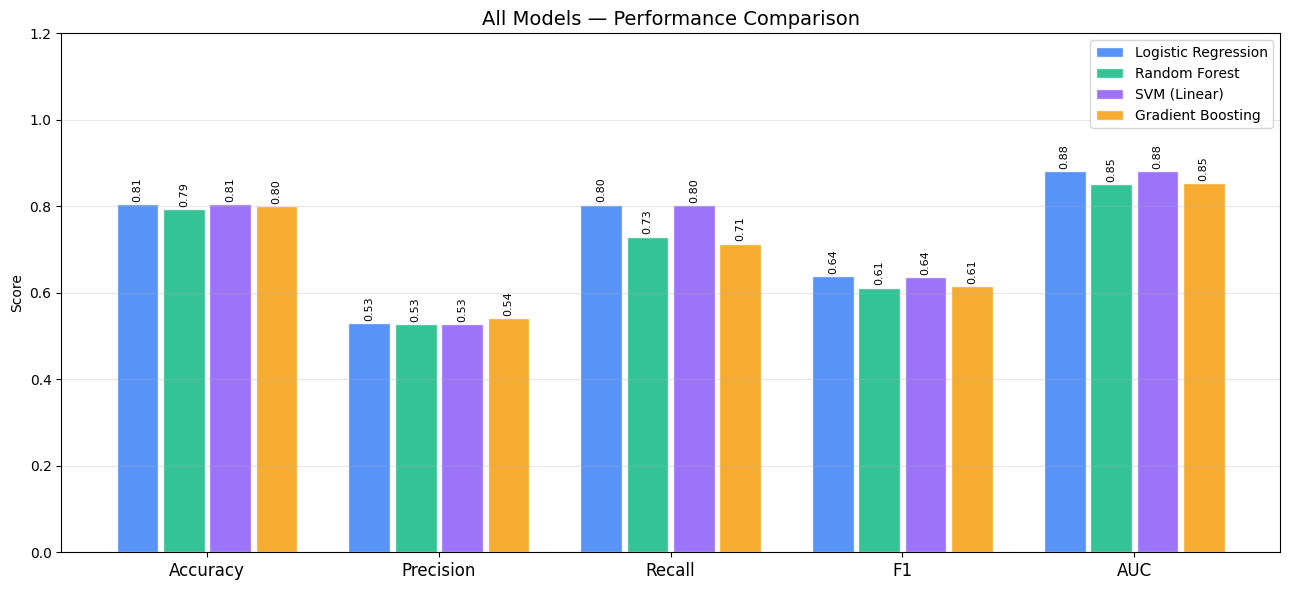

In [14]:
print("=" * 60)
print("  2.5 — All Models Summary")
print("=" * 60)

summary_df = pd.DataFrame(all_model_results).T
summary_df = summary_df[["Accuracy","Precision","Recall","F1","AUC"]].round(3)
print("All models — macro-averaged metrics:")
print(summary_df.to_string())

# Visual comparison
metrics = ["Accuracy","Precision","Recall","F1","AUC"]
x = np.arange(len(metrics))
width = 0.2
colors = ["#3b82f6","#10b981","#8b5cf6","#f59e0b"]
labels = list(summary_df.index)

fig, ax = plt.subplots(figsize=(13, 6))
for i, (label, row) in enumerate(summary_df.iterrows()):
    offset = (i - len(labels)/2 + 0.5) * width
    bars   = ax.bar(x+offset, row[metrics].values, width*0.9,
                    label=label, color=colors[i], alpha=0.85, edgecolor="white")
    for b, v in zip(bars, row[metrics].values):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
                f"{v:.2f}", ha="center", va="bottom", fontsize=8, rotation=90)
ax.set_xticks(x); ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.2); ax.set_ylabel("Score")
ax.set_title("All Models — Performance Comparison", fontsize=14)
ax.legend(loc="upper right"); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

---
## Section 2.6 — Hyperparameter Tuning
Every model has settings chosen before training — like how deep the trees grow or how strong the regularisation is. Random search with 5-fold cross-validation is used to find the settings that actually work best instead of guessing.

In [15]:
# Additional imports for hyperparameter tuning
from sklearn.model_selection  import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics          import make_scorer
from imblearn.pipeline        import Pipeline as ImbPipeline  # SMOTE-aware pipeline
from scipy.stats              import loguniform, randint, uniform
import time

# Score by F1 on the Rain class (minority class — most important)
f1_scorer = make_scorer(f1_score, zero_division=0)

# 5-fold stratified CV — preserves Rain/No-Rain ratio in every fold
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

tuning_results = {}  # stores best params + scores for final comparison
print("Tuning setup complete")

Tuning setup complete


### 2.6.1 — Logistic Regression Tuning
The best regularisation strength `C` and whether L1 or L2 penalty works better for this dataset are searched.

In [16]:
start = time.time()

lr_pipe = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf",   LogisticRegression(max_iter=2000, random_state=42, solver="saga"))
])

lr_param_dist = {
    "clf__C":       loguniform(0.001, 10),   # regularisation: 0.001 to 10
    "clf__penalty": ["l1", "l2"],             # lasso vs ridge
    "smote__k_neighbors": [3, 5, 7],          # SMOTE neighbourhood size
}

lr_search = RandomizedSearchCV(
    lr_pipe, lr_param_dist,
    n_iter=30,           # try 30 random combinations
    cv=CV,
    scoring=f1_scorer,   # optimise for Rain class F1
    n_jobs=-1,           # use all CPU cores
    random_state=42,
    verbose=1
)

lr_search.fit(X_train, y_train)

print(f"\nTime: {time.time()-start:.0f}s")
print(f"Best params : {lr_search.best_params_}")
print(f"Best CV-F1  : {lr_search.best_score_:.4f}")

# Evaluate on test set
lr_tuned_pred = lr_search.predict(X_test)
lr_tuned_prob = lr_search.predict_proba(X_test)[:,1]
lr_tuned_f1   = f1_score(y_test, lr_tuned_pred, zero_division=0)
lr_tuned_auc  = roc_auc_score(y_test, lr_tuned_prob)

print(f"\nTest set results after tuning:")
print(f"  F1  = {lr_tuned_f1:.4f}  (was {all_model_results["Logistic Regression"]["F1"]:.4f})")
print(f"  AUC = {lr_tuned_auc:.4f}  (was {all_model_results["Logistic Regression"]["AUC"]:.4f})")
print(f"  Improvement: {(lr_tuned_f1 - all_model_results["Logistic Regression"]["F1"])*100:+.2f}% F1")

tuning_results["LR (tuned)"] = {"F1": lr_tuned_f1, "AUC": lr_tuned_auc,
    "best_params": lr_search.best_params_}

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Time: 121s
Best params : {'clf__C': np.float64(0.03148911647956861), 'clf__penalty': 'l1', 'smote__k_neighbors': 7}
Best CV-F1  : 0.6024

Test set results after tuning:
  F1  = 0.6092  (was 0.6388)
  AUC = 0.8539  (was 0.8815)
  Improvement: -2.96% F1


### 2.6.2b — SVM Tuning
The margin hardness parameter `C` is tuned — the default of 1.0 is arbitrary and the optimal value for noisy weather data could be anywhere from 0.001 to 100.

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Time: 69s
Best params : {'clf__estimator__C': np.float64(0.006026889128682512), 'clf__estimator__max_iter': 3000, 'smote__k_neighbors': 7}
Best CV-F1  : 0.6016
Test F1  = 0.6076  (was 0.6368)
Test AUC = 0.8537  (was 0.8810)
Improvement: -2.92% F1


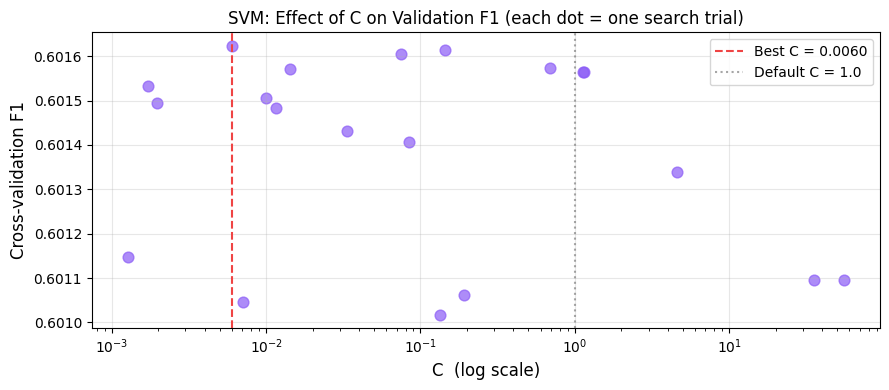

Best C < 1: data needs more regularisation than default
  The boundary benefits from a wider margin (noisy/overlapping classes)


In [17]:
import time
from sklearn.svm             import LinearSVC
from sklearn.calibration     import CalibratedClassifierCV
from imblearn.over_sampling  import SMOTE
from imblearn.pipeline       import Pipeline as ImbPipeline
from scipy.stats             import loguniform

start = time.time()

svm_pipe = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf",   CalibratedClassifierCV(
                  LinearSVC(class_weight="balanced", random_state=42),
                  cv=3))
])

svm_param_dist = {
    "clf__estimator__C":        loguniform(0.001, 100),  # log-uniform: 0.001 to 100
    "clf__estimator__max_iter": [1000, 2000, 3000],       # convergence stability
    "smote__k_neighbors":       [3, 5, 7],
}

svm_search = RandomizedSearchCV(
    svm_pipe, svm_param_dist,
    n_iter=20,        # fewer than LR/RF/GB — calibration overhead is higher
    cv=CV,
    scoring=f1_scorer,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

svm_search.fit(X_train, y_train)

print(f"Time: {time.time()-start:.0f}s")
print(f"Best params : {svm_search.best_params_}")
print(f"Best CV-F1  : {svm_search.best_score_:.4f}")

svm_tuned_pred = svm_search.predict(X_test)
svm_tuned_prob = svm_search.predict_proba(X_test)[:,1]
svm_tuned_f1   = f1_score(y_test, svm_tuned_pred, zero_division=0)
svm_tuned_auc  = roc_auc_score(y_test, svm_tuned_prob)

svm_default_f1  = all_model_results["SVM (Linear)"]["F1"]
svm_default_auc = all_model_results["SVM (Linear)"]["AUC"]

print(f"Test F1  = {svm_tuned_f1:.4f}  (was {svm_default_f1:.4f})")
print(f"Test AUC = {svm_tuned_auc:.4f}  (was {svm_default_auc:.4f})")
print(f"Improvement: {(svm_tuned_f1 - svm_default_f1)*100:+.2f}% F1")

# Visualise: effect of C on cross-validation F1
cv_results = svm_search.cv_results_
c_values   = [p["clf__estimator__C"] for p in cv_results["params"]]
cv_f1      = cv_results["mean_test_score"]

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(c_values, cv_f1, alpha=0.7, color="#8b5cf6", s=60)
best_c = svm_search.best_params_["clf__estimator__C"]
ax.axvline(x=best_c, color="#ef4444", linestyle="--",
           label=f"Best C = {best_c:.4f}")
ax.axvline(x=1.0, color="grey", linestyle=":", alpha=0.7, label="Default C = 1.0")
ax.set_xscale("log")
ax.set_xlabel("C  (log scale)", fontsize=12)
ax.set_ylabel("Cross-validation F1", fontsize=12)
ax.set_title("SVM: Effect of C on Validation F1 (each dot = one search trial)", fontsize=12)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Interpret the result
if best_c < 0.5:
    print("Best C < 1: data needs more regularisation than default")
    print("  The boundary benefits from a wider margin (noisy/overlapping classes)")
elif best_c > 2.0:
    print("Best C > 1: data supports a tighter boundary than default")
    print("  The classes are more separable than the default assumed")
else:
    print("Best C near 1.0: default was already close to optimal")

tuning_results["SVM (tuned)"] = {"F1": svm_tuned_f1, "AUC": svm_tuned_auc,
    "best_params": svm_search.best_params_}

### 2.6.2 — Random Forest Tuning
The best tree depth, number of trees, and how many features to consider at each split are searched.

In [18]:
start = time.time()

rf_pipe = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf",   RandomForestClassifier(random_state=42, n_jobs=-1,
                                     class_weight="balanced"))
])

rf_param_dist = {
    "clf__n_estimators":    randint(100, 400),      # 100 to 400 trees
    "clf__max_depth":       [6, 8, 12, 15, None],   # None = fully grown
    "clf__min_samples_leaf": randint(2, 12),        # leaf size regularisation
    "clf__max_features":    ["sqrt", "log2", 0.4],  # feature subset per split
    "smote__k_neighbors":   [3, 5, 7],
}

rf_search = RandomizedSearchCV(
    rf_pipe, rf_param_dist,
    n_iter=30,
    cv=CV,
    scoring=f1_scorer,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_search.fit(X_train, y_train)

print(f"\nTime: {time.time()-start:.0f}s")
print(f"Best params : {rf_search.best_params_}")
print(f"Best CV-F1  : {rf_search.best_score_:.4f}")

rf_tuned_pred = rf_search.predict(X_test)
rf_tuned_prob = rf_search.predict_proba(X_test)[:,1]
rf_tuned_f1   = f1_score(y_test, rf_tuned_pred, zero_division=0)
rf_tuned_auc  = roc_auc_score(y_test, rf_tuned_prob)

print(f"\nTest set results after tuning:")
print(f"  F1  = {rf_tuned_f1:.4f}  (was {all_model_results["Random Forest"]["F1"]:.4f})")
print(f"  AUC = {rf_tuned_auc:.4f}  (was {all_model_results["Random Forest"]["AUC"]:.4f})")
print(f"  Improvement: {(rf_tuned_f1 - all_model_results["Random Forest"]["F1"])*100:+.2f}% F1")

tuning_results["RF (tuned)"] = {"F1": rf_tuned_f1, "AUC": rf_tuned_auc,
    "best_params": rf_search.best_params_}

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Time: 1707s
Best params : {'clf__max_depth': 15, 'clf__max_features': 0.4, 'clf__min_samples_leaf': 4, 'clf__n_estimators': 180, 'smote__k_neighbors': 7}
Best CV-F1  : 0.6377

Test set results after tuning:
  F1  = 0.6443  (was 0.6120)
  AUC = 0.8734  (was 0.8515)
  Improvement: +3.24% F1


### 2.6.3 — Gradient Boosting Tuning
The learning rate, number of trees, tree depth, and subsampling rate are tuned — these interact with each other so random search handles them together.

In [19]:
start = time.time()

gb_pipe = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf",   GradientBoostingClassifier(random_state=42))
])

gb_param_dist = {
    "clf__n_estimators":     randint(100, 400),
    "clf__learning_rate":    loguniform(0.01, 0.3),
    "clf__max_depth":        [2, 3, 4, 5],
    "clf__subsample":        uniform(0.6, 0.4),
    "clf__min_samples_leaf": randint(2, 10),
    "smote__k_neighbors":    [3, 5, 7],
}

gb_search = RandomizedSearchCV(
    gb_pipe, gb_param_dist,
    n_iter=30, cv=CV, scoring=f1_scorer,
    n_jobs=-1, random_state=42, verbose=1
)

gb_search.fit(X_train, y_train)

print(f"\nTime: {time.time()-start:.0f}s")
print(f"Best params : {gb_search.best_params_}")
print(f"Best CV-F1  : {gb_search.best_score_:.4f}")

gb_tuned_pred  = gb_search.predict(X_test)
gb_tuned_prob  = gb_search.predict_proba(X_test)[:,1]
gb_tuned_f1    = f1_score(y_test, gb_tuned_pred, zero_division=0)
gb_tuned_auc   = roc_auc_score(y_test, gb_tuned_prob)
gb_default_f1  = all_model_results["Gradient Boosting"]["F1"]
gb_default_auc = all_model_results["Gradient Boosting"]["AUC"]

print(f"\nTest F1  = {gb_tuned_f1:.4f}  (was {gb_default_f1:.4f})")
print(f"Test AUC = {gb_tuned_auc:.4f}  (was {gb_default_auc:.4f})")
print(f"Improvement: {(gb_tuned_f1 - gb_default_f1)*100:+.2f}% F1")

tuning_results["GB (tuned)"] = {
    "F1":          gb_tuned_f1,
    "AUC":         gb_tuned_auc,
    "best_params": gb_search.best_params_
}

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Time: 4294s
Best params : {'clf__learning_rate': np.float64(0.028797752657070342), 'clf__max_depth': 5, 'clf__min_samples_leaf': 6, 'clf__n_estimators': 198, 'clf__subsample': np.float64(0.8365191150830908), 'smote__k_neighbors': 5}
Best CV-F1  : 0.6233

Test F1  = 0.6277  (was 0.6153)
Test AUC = 0.8616  (was 0.8543)
Improvement: +1.24% F1


### 2.6.4 — Threshold Tuning
All models predict Rain when probability exceeds 0.5 by default, but that threshold is arbitrary — the value that actually maximises F1 on this imbalanced dataset is found here, with no retraining needed.

Default threshold (0.50):  F1 = 0.6277
Optimal threshold (0.473): F1 = 0.6292
Improvement from threshold tuning: +0.15%


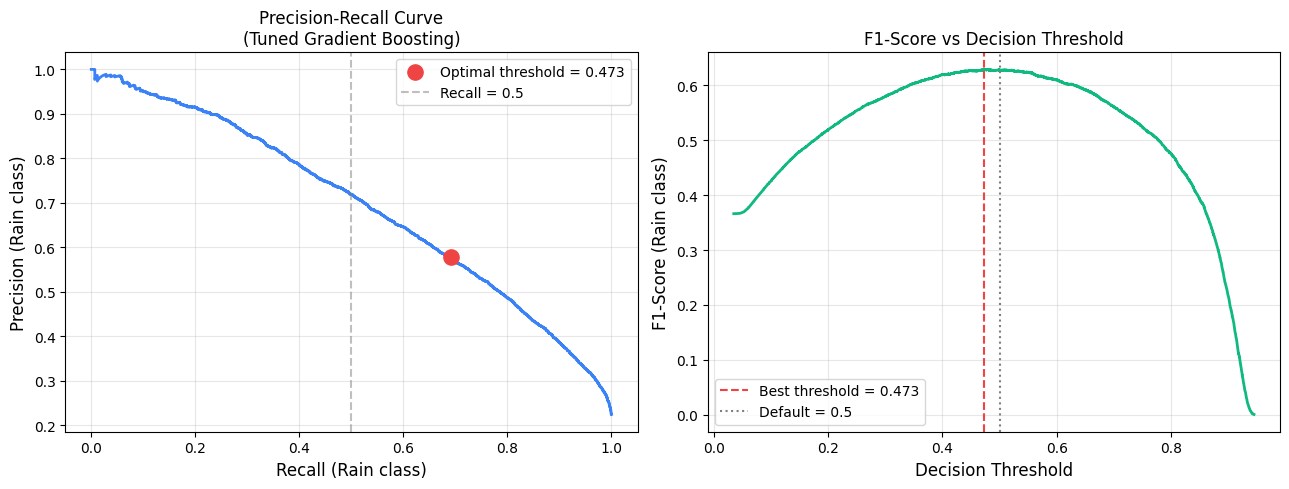


Conclusion: threshold 0.473 captures the optimal Precision/Recall tradeoff


In [20]:
from sklearn.metrics import precision_recall_curve

# Apply threshold tuning to the best model (Gradient Boosting)
# Use the probabilities from the tuned GB model on the test set
prec_arr, rec_arr, thresholds = precision_recall_curve(y_test, gb_tuned_prob)

# F1 at each threshold
f1_arr = np.where((prec_arr[:-1]+rec_arr[:-1])==0, 0,
                   2*prec_arr[:-1]*rec_arr[:-1]/(prec_arr[:-1]+rec_arr[:-1]))

best_thresh_idx = np.argmax(f1_arr)
best_thresh     = thresholds[best_thresh_idx]
best_f1_thresh  = f1_arr[best_thresh_idx]

print(f"Default threshold (0.50):  F1 = {gb_tuned_f1:.4f}")
print(f"Optimal threshold ({best_thresh:.3f}): F1 = {best_f1_thresh:.4f}")
print(f"Improvement from threshold tuning: {(best_f1_thresh-gb_tuned_f1)*100:+.2f}%")

# Precision-Recall curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: PR curve
axes[0].plot(rec_arr, prec_arr, "#3b82f6", linewidth=2)
axes[0].scatter(rec_arr[best_thresh_idx], prec_arr[best_thresh_idx],
                s=120, color="#ef4444", zorder=5,
                label=f"Optimal threshold = {best_thresh:.3f}")
axes[0].axvline(x=0.5, color="grey", linestyle="--", alpha=0.5, label="Recall = 0.5")
axes[0].set_xlabel("Recall (Rain class)", fontsize=12)
axes[0].set_ylabel("Precision (Rain class)", fontsize=12)
axes[0].set_title("Precision-Recall Curve\n(Tuned Gradient Boosting)", fontsize=12)
axes[0].legend(); axes[0].grid(alpha=0.3)

# Right: F1 vs threshold
axes[1].plot(thresholds, f1_arr, "#10b981", linewidth=2)
axes[1].axvline(x=best_thresh, color="#ef4444", linestyle="--",
                label=f"Best threshold = {best_thresh:.3f}")
axes[1].axvline(x=0.5, color="grey", linestyle=":", label="Default = 0.5")
axes[1].set_xlabel("Decision Threshold", fontsize=12)
axes[1].set_ylabel("F1-Score (Rain class)", fontsize=12)
axes[1].set_title("F1-Score vs Decision Threshold", fontsize=12)
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(f"\nConclusion: threshold {best_thresh:.3f} captures the optimal Precision/Recall tradeoff")

### 2.6.5 — Before vs After Tuning
A direct comparison of every model's performance before and after hyperparameter search.

Before vs After Hyperparameter Tuning (all 4 models):
       F1 Before  F1 After  F1 Delta  AUC Before  AUC After  AUC Delta
Model                                                                 
LR        0.6388    0.6092   -0.0296      0.8815     0.8539    -0.0275
SVM       0.6368    0.6076   -0.0292      0.8810     0.8537    -0.0273
RF        0.6120    0.6443    0.0324      0.8515     0.8734     0.0220
GB        0.6153    0.6277    0.0124      0.8543     0.8616     0.0073


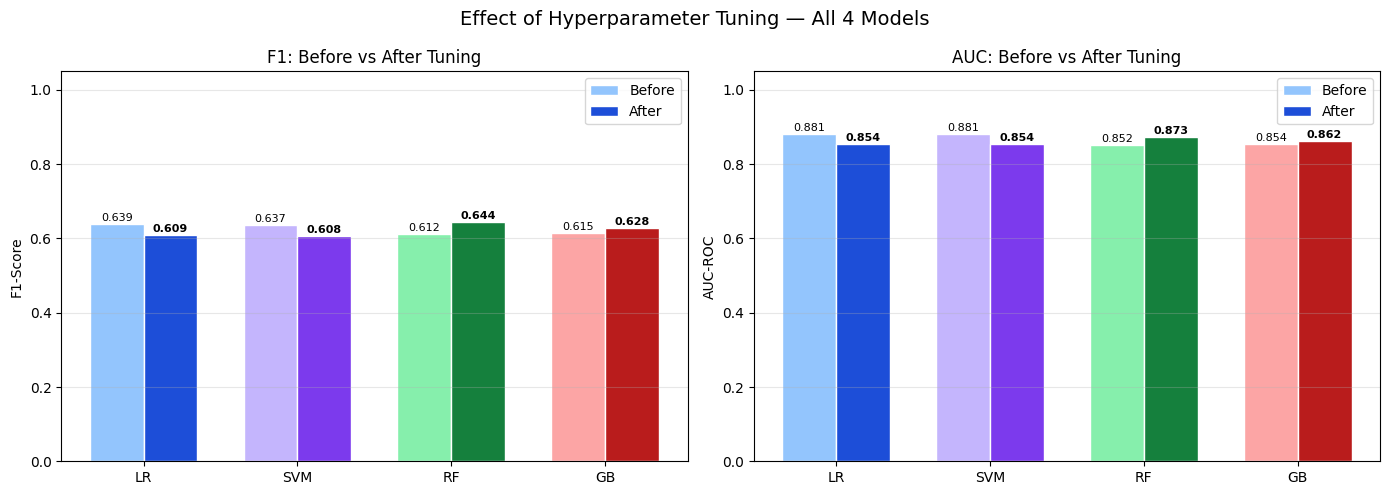

Best model after tuning : RF (tuned)
  F1  = 0.6443
  AUC = 0.8734


In [21]:
base_models = {
    "LR":  all_model_results["Logistic Regression"],
    "SVM": all_model_results["SVM (Linear)"],
    "RF":  all_model_results["Random Forest"],
    "GB":  all_model_results["Gradient Boosting"],
}
tuned_keys = ["LR (tuned)", "SVM (tuned)", "RF (tuned)", "GB (tuned)"]
rows = []
for (label, dval), tkey in zip(base_models.items(), tuned_keys):
    tval = tuning_results.get(tkey, {"F1": float("nan"), "AUC": float("nan")})
    rows.append({
        "Model":      label,
        "F1 Before":  round(dval["F1"],  4),
        "F1 After":   round(tval["F1"],  4),
        "F1 Delta":   round(tval["F1"] - dval["F1"], 4),
        "AUC Before": round(dval["AUC"], 4),
        "AUC After":  round(tval["AUC"], 4),
        "AUC Delta":  round(tval["AUC"] - dval["AUC"], 4),
    })
comp = pd.DataFrame(rows).set_index("Model")
print("Before vs After Hyperparameter Tuning (all 4 models):")
print("=" * 68)
print(comp.to_string())
print("=" * 68)
# Grouped bar chart: F1 and AUC before/after for all 4 models
models    = [r["Model"]     for r in rows]
f1_bef    = [r["F1 Before"]  for r in rows]
f1_aft    = [r["F1 After"]   for r in rows]
auc_bef   = [r["AUC Before"] for r in rows]
auc_aft   = [r["AUC After"]  for r in rows]
x = np.arange(len(models)); w = 0.35
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
clr_b = ["#93C5FD","#C4B5FD","#86EFAC","#FCA5A5"]
clr_a = ["#1D4ED8","#7C3AED","#15803D","#B91C1C"]
for ax, bvals, avals, ylabel, title in [
    (axes[0], f1_bef,  f1_aft,  "F1-Score", "F1: Before vs After Tuning"),
    (axes[1], auc_bef, auc_aft, "AUC-ROC",  "AUC: Before vs After Tuning"),
]:
    for i, (bv, av, cb, ca) in enumerate(zip(bvals, avals, clr_b, clr_a)):
        ax.bar(i-w/2, bv, w, color=cb, edgecolor="white",
               label="Before" if i==0 else "")
        ax.bar(i+w/2, av, w, color=ca, edgecolor="white",
               label="After"  if i==0 else "")
        ax.text(i-w/2, bv+0.003, f"{bv:.3f}", ha="center", va="bottom", fontsize=8)
        ax.text(i+w/2, av+0.003, f"{av:.3f}", ha="center", va="bottom",
                fontsize=8, fontweight="bold")
    ax.set_xticks(range(len(models))); ax.set_xticklabels(models)
    ax.set_ylim(0, 1.05); ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=12)
    ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.suptitle("Effect of Hyperparameter Tuning — All 4 Models", fontsize=14)
plt.tight_layout(); plt.show()
best_tuned = max(tuning_results, key=lambda k: tuning_results[k]["F1"])
print(f"Best model after tuning : {best_tuned}")
best_f1  = tuning_results[best_tuned]["F1"]
print(f"  F1  = {best_f1:.4f}")
best_auc = tuning_results[best_tuned]["AUC"]
print(f"  AUC = {best_auc:.4f}")


### 2.6.6 — Learning Curves
Model performance is plotted against training data size to check whether overfitting, underfitting, or a good fit is present — and whether adding more data would help.

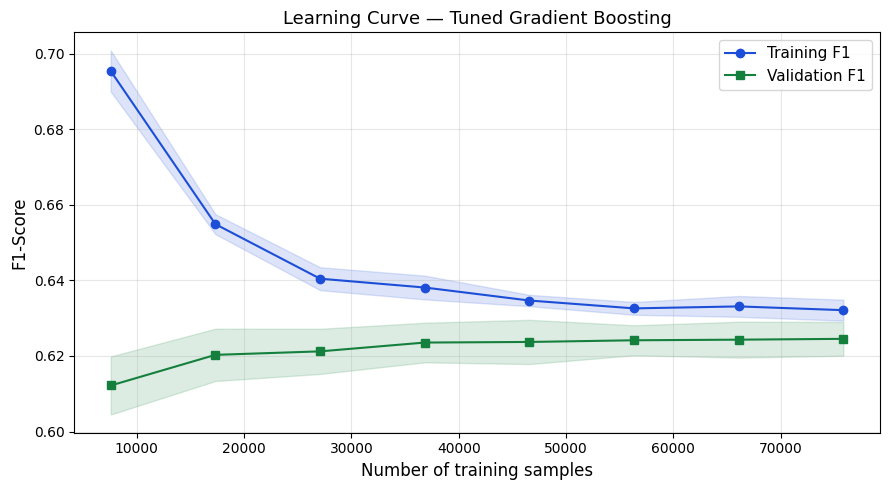

Final training F1   : 0.6321
Final validation F1 : 0.6245
Train-Val gap       : 0.0076
Diagnosis: Good fit — small gap, more data unlikely to help much


In [22]:
from sklearn.model_selection import learning_curve

# Use the best tuned GB for the learning curve
best_gb = gb_search.best_estimator_

train_sizes, train_scores, val_scores = learning_curve(
    best_gb, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=3,
    scoring=f1_scorer,
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_mean, "o-", color="#1D4ED8", label="Training F1")
ax.fill_between(train_sizes,
                train_mean-train_std, train_mean+train_std,
                alpha=0.15, color="#1D4ED8")
ax.plot(train_sizes, val_mean, "s-", color="#15803D", label="Validation F1")
ax.fill_between(train_sizes,
                val_mean-val_std, val_mean+val_std,
                alpha=0.15, color="#15803D")
ax.set_xlabel("Number of training samples", fontsize=12)
ax.set_ylabel("F1-Score", fontsize=12)
ax.set_title("Learning Curve — Tuned Gradient Boosting", fontsize=13)
ax.legend(fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

gap = train_mean[-1] - val_mean[-1]
print(f"Final training F1   : {train_mean[-1]:.4f}")
print(f"Final validation F1 : {val_mean[-1]:.4f}")
print(f"Train-Val gap       : {gap:.4f}")
if gap < 0.05:
    print("Diagnosis: Good fit — small gap, more data unlikely to help much")
elif gap < 0.15:
    print("Diagnosis: Slight variance — more data or regularisation would help")
else:
    print("Diagnosis: High variance — model needs stronger regularisation or more data")

---
## Section 2.7 — Cloud Image Classification
A visual dimension is added to the project: a CNN trained on 2,543 sky photographs classifies cloud types and predicts whether the sky looks like it will rain. This is the same binary question as the tabular models, just answered through images instead of sensor numbers.

**Rain-producing clouds:** Cumulonimbus (Cb), Nimbostratus (Ns), Cumulus (Cu) → labelled Rain
**Non-rain clouds:** Cirrus, Stratocumulus, Stratus, and others → labelled No Rain

| Cloud | Code | Rain? |
|---|---|---|
| Cumulonimbus | Cb | Yes |
| Nimbostratus | Ns | Yes |
| Cumulus | Cu | Yes |
| All others | — | No |


In [23]:

import os, io, zipfile, random
import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import seaborn           as sns

import tensorflow as tf
from tensorflow.keras              import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers   import Adam
from tensorflow.keras.callbacks    import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics         import (classification_report, confusion_matrix,
                                      accuracy_score, f1_score, roc_auc_score)
from PIL                     import Image

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {len(tf.config.list_physical_devices('GPU')) > 0}")
random.seed(42); np.random.seed(42); tf.random.set_seed(42)

TensorFlow version : 2.21.0
GPU available      : False


In [24]:
# Set the path to your CCSN.zip file.
# If it is in the same folder as this notebook, just use the filename.
ZIP_PATH = "CCSN.zip"

#   Cb = Cumulonimbus (thunderstorm)     → Rain
#   Ns = Nimbostratus (continuous rain)  → Rain
#   Cu = Cumulus (shower clouds)         → Rain
#   All others                           → No Rain
RAIN_CLASSES = {"Cb", "Ns", "Cu"}

CLASS_NAMES = {
    "Cb":"Cumulonimbus", "Ns":"Nimbostratus", "Cu":"Cumulus",
    "Ac":"Altocumulus",  "As":"Altostratus",  "Cc":"Cirrocumulus",
    "Ci":"Cirrus",       "Cs":"Cirrostratus", "Ct":"Contrail",
    "Sc":"Stratocumulus","St":"Stratus"
}

IMG_SIZE = 128   # resize to 128×128 — fast yet sufficient for transfer learning

images, labels, cloud_types = [], [], []

z = zipfile.ZipFile(ZIP_PATH)
all_jpgs = [
    n for n in z.namelist()
    if len(n.split("/")) == 3
    and n.split("/")[2].endswith(".jpg")
    and not n.split("/")[2].startswith("._")
]

print(f"Loading {len(all_jpgs)} images …")
for name in all_jpgs:
    cls = name.split("/")[1]
    raw = z.read(name)
    img = Image.open(io.BytesIO(raw)).convert("RGB")
    img = img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
    images.append(np.array(img, dtype=np.float32) / 255.0)   # normalise to [0,1]
    labels.append(1 if cls in RAIN_CLASSES else 0)
    cloud_types.append(cls)

X_img = np.array(images)    # shape: (2543, 128, 128, 3)
y_img = np.array(labels)    # shape: (2543,)

print(f"Dataset shape  : {X_img.shape}")
print(f"Rain images    : {y_img.sum()} ({y_img.mean():.1%})")
print(f"No Rain images : {(1-y_img).sum()} ({(1-y_img).mean():.1%})")

Loading 2543 images …
Dataset shape  : (2543, 128, 128, 3)
Rain images    : 698 (27.4%)
No Rain images : 1845 (72.6%)


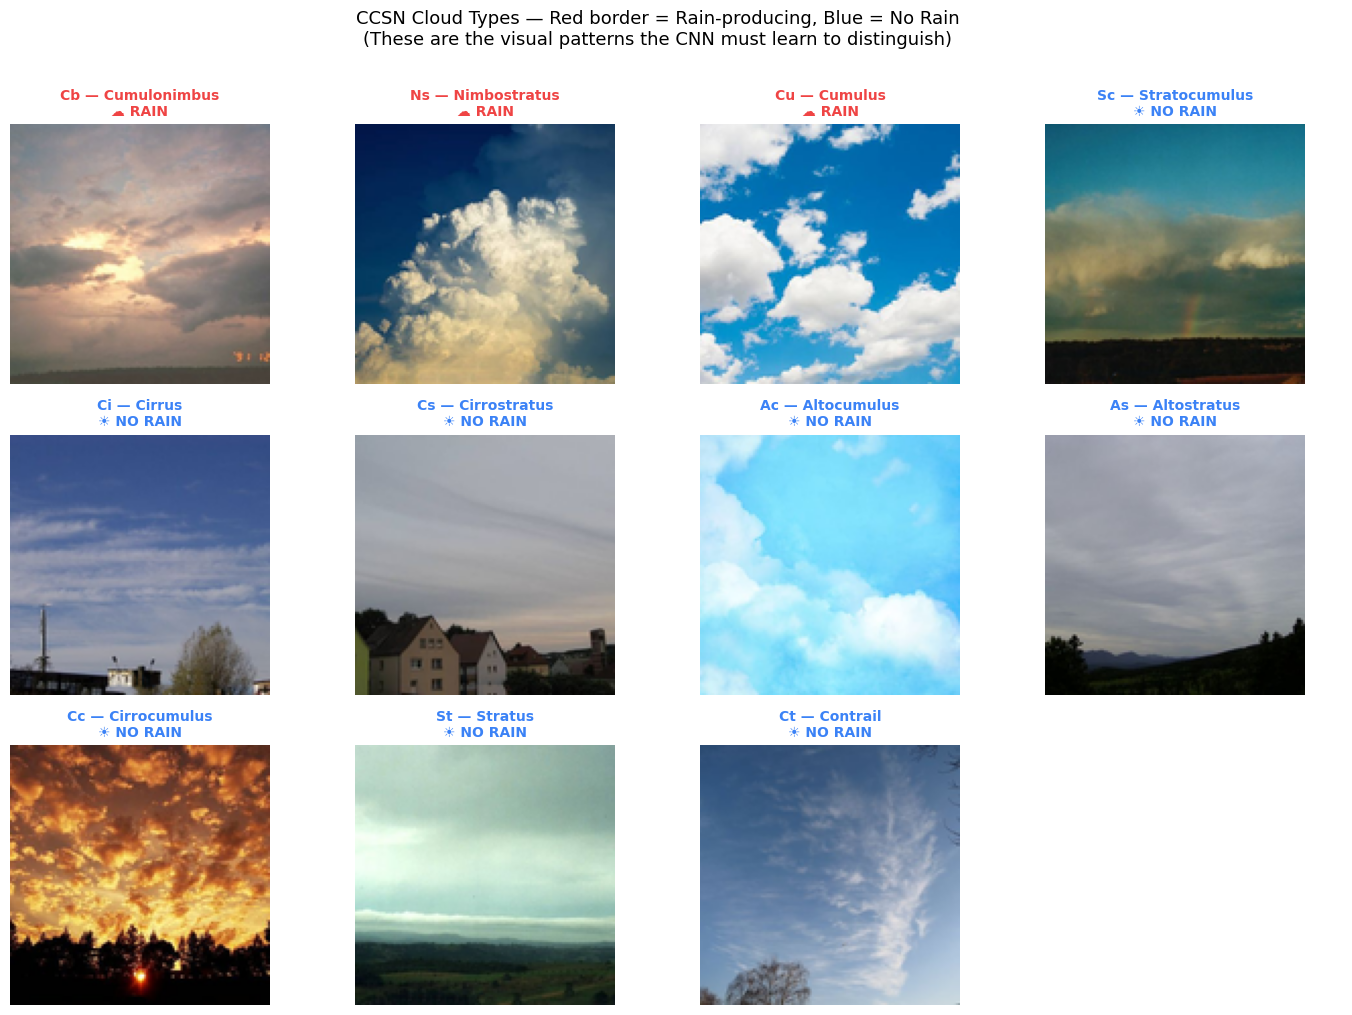

In [26]:

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

cloud_type_arr = np.array(cloud_types)
shown = 0

for cls in ["Cb","Ns","Cu","Sc","Ci","Cs","Ac","As","Cc","St","Ct"]:
    idx = np.where(cloud_type_arr == cls)[0]
    sample_idx = idx[np.random.randint(len(idx))]
    ax = axes[shown]
    ax.imshow(X_img[sample_idx])
    label_str = "☁ RAIN" if y_img[sample_idx] == 1 else "☀ NO RAIN"
    border_col = "#ef4444" if y_img[sample_idx] == 1 else "#3b82f6"
    ax.set_title(
        f"{cls} — {CLASS_NAMES[cls]}\n{label_str}",
        fontsize=10, color=border_col, fontweight="bold"
    )
    for spine in ax.spines.values():
        spine.set_edgecolor(border_col); spine.set_linewidth(3)
    ax.axis("off")
    shown += 1

axes[-1].axis("off")   # hide the 12th empty panel
plt.suptitle(
    "CCSN Cloud Types — Red border = Rain-producing, Blue = No Rain\n"
    "(These are the visual patterns the CNN must learn to distinguish)",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

In [27]:

X_tv, X_test_img, y_tv, y_test_img = train_test_split(
    X_img, y_img, test_size=0.15, stratify=y_img, random_state=42)

X_train_img, X_val_img, y_train_img, y_val_img = train_test_split(
    X_tv, y_tv, test_size=0.15, stratify=y_tv, random_state=42)

print(f"Train : {len(X_train_img):>5} images  (Rain: {y_train_img.mean():.1%})")
print(f"Val   : {len(X_val_img):>5} images  (Rain: {y_val_img.mean():.1%})")
print(f"Test  : {len(X_test_img):>5} images  (Rain: {y_test_img.mean():.1%})")

n_no_rain = (y_train_img == 0).sum()
n_rain    = (y_train_img == 1).sum()
class_weight_img = {
    0: 1.0,
    1: n_no_rain / n_rain      # weight Rain class by imbalance ratio
}
print(f"\nClass weights: {class_weight_img}")

Train :  1836 images  (Rain: 27.5%)
Val   :   325 images  (Rain: 27.4%)
Test  :   382 images  (Rain: 27.5%)

Class weights: {0: 1.0, 1: np.float64(2.642857142857143)}


In [28]:

base_model = MobileNetV2(
    weights="imagenet",          # pretrained feature extractor
    include_top=False,           # remove original ImageNet classifier
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False     # freeze all 154 base layers

inputs  = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(128, activation="relu")(x)
x       = layers.Dropout(0.4)(x)               # regularisation
outputs = layers.Dense(1, activation="sigmoid")(x)

cnn_model = models.Model(inputs, outputs)

cnn_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

total_params    = cnn_model.count_params()
trainable       = sum(tf.size(v).numpy() for v in cnn_model.trainable_variables)
non_trainable   = total_params - trainable
print(f"Total parameters     : {total_params:,}")
print(f"Trainable (our head) : {trainable:,}  ← only these learn")
print(f"Frozen (MobileNetV2) : {non_trainable:,}  ← pretrained knowledge")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 17s 2us/step
Total parameters     : 2,422,081
Trainable (our head) : 164,097  ← only these learn
Frozen (MobileNetV2) : 2,257,984  ← pretrained knowledge


In [29]:

callbacks = [
    EarlyStopping(monitor="val_auc", patience=8,
                  restore_best_weights=True, mode="max"),
    ReduceLROnPlateau(monitor="val_auc", factor=0.5,
                      patience=4, mode="max", verbose=1)
]

print("Phase 1 — Training classification head (base frozen) …")
history1 = cnn_model.fit(
    X_train_img, y_train_img,
    validation_data=(X_val_img, y_val_img),
    epochs=30,
    batch_size=32,
    class_weight=class_weight_img,
    callbacks=callbacks,
    verbose=1
)
print(f"\nPhase 1 complete. Best val AUC: {max(history1.history['val_auc']):.4f}")

Phase 1 — Training classification head (base frozen) …
Epoch 1/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 118ms/step - accuracy: 0.6639 - auc: 0.7343 - loss: 0.9189 - val_accuracy: 0.7908 - val_auc: 0.8671 - val_loss: 0.4656 - learning_rate: 0.0010
Epoch 2/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - accuracy: 0.7364 - auc: 0.8310 - loss: 0.7291 - val_accuracy: 0.7846 - val_auc: 0.8696 - val_loss: 0.4369 - learning_rate: 0.0010
Epoch 3/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.7712 - auc: 0.8602 - loss: 0.6752 - val_accuracy: 0.7846 - val_auc: 0.8705 - val_loss: 0.4339 - learning_rate: 0.0010
Epoch 4/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.7859 - auc: 0.8796 - loss: 0.6305 - val_accuracy: 0.7815 - val_auc: 0.8626 - val_loss: 0.4473 - learning_rate: 0.0010
Epoch 5/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.8012 - auc: 0.8946 - loss: 0.5919 - val_accuracy: 0.8154 - val_auc: 0.8760 - val_loss: 0.4235 - learning_rate: 0.0010
Epoch 6/30
58/58 ━━━━━━━━━━━

In [30]:

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_ft = sum(tf.size(v).numpy() for v in cnn_model.trainable_variables)
print(f"Fine-tuning trainable parameters: {trainable_ft:,}")

cnn_model.compile(
    optimizer=Adam(learning_rate=1e-5),   # much lower LR for fine-tuning
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

print("Phase 2 — Fine-tuning top layers …")
history2 = cnn_model.fit(
    X_train_img, y_train_img,
    validation_data=(X_val_img, y_val_img),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_img,
    callbacks=callbacks,
    verbose=1
)
print(f"\nPhase 2 complete. Best val AUC: {max(history2.history['val_auc']):.4f}")

Fine-tuning trainable parameters: 1,690,497
Phase 2 — Fine-tuning top layers …
Epoch 1/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 14s 139ms/step - accuracy: 0.7347 - auc: 0.6955 - loss: 3.2908 - val_accuracy: 0.8246 - val_auc: 0.8803 - val_loss: 0.3857 - learning_rate: 1.0000e-05
Epoch 2/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - accuracy: 0.7647 - auc: 0.7911 - loss: 1.8876 - val_accuracy: 0.8185 - val_auc: 0.8789 - val_loss: 0.3815 - learning_rate: 1.0000e-05
Epoch 3/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - accuracy: 0.7990 - auc: 0.8490 - loss: 1.2096 - val_accuracy: 0.8123 - val_auc: 0.8790 - val_loss: 0.3856 - learning_rate: 1.0000e-05
Epoch 4/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step - accuracy: 0.8246 - auc: 0.8789 - loss: 0.8686 - val_accuracy: 0.8123 - val_auc: 0.8777 - val_loss: 0.3893 - learning_rate: 1.0000e-05
Epoch 5/20
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.8328 - auc: 0.8991 - loss: 0.6789
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.99999987368937

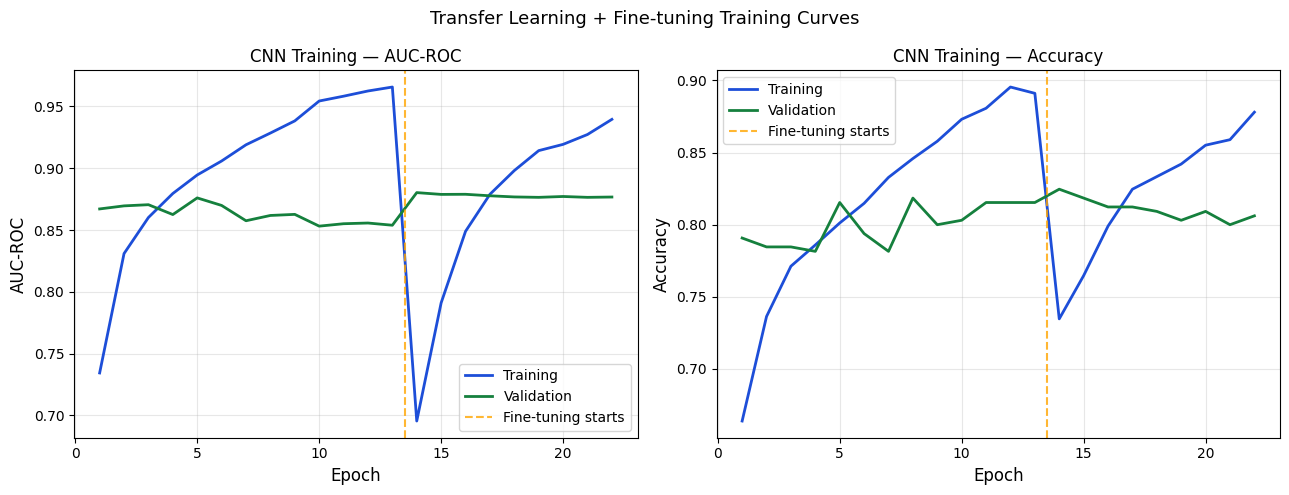

In [31]:

auc_train = history1.history["auc"]     + history2.history["auc"]
auc_val   = history1.history["val_auc"] + history2.history["val_auc"]
acc_train = history1.history["accuracy"]     + history2.history["accuracy"]
acc_val   = history1.history["val_accuracy"] + history2.history["val_accuracy"]
phase1_end = len(history1.history["auc"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, train_vals, val_vals, metric in [
    (axes[0], auc_train,  auc_val,   "AUC-ROC"),
    (axes[1], acc_train,  acc_val,   "Accuracy"),
]:
    epochs = range(1, len(train_vals)+1)
    ax.plot(epochs, train_vals, "#1D4ED8", linewidth=2, label="Training")
    ax.plot(epochs, val_vals,   "#15803D", linewidth=2, label="Validation")
    ax.axvline(x=phase1_end+0.5, color="orange", linestyle="--",
               label="Fine-tuning starts", alpha=0.8)
    ax.set_xlabel("Epoch", fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f"CNN Training — {metric}", fontsize=12)
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle("Transfer Learning + Fine-tuning Training Curves", fontsize=13)
plt.tight_layout()
plt.show()

  CNN Cloud Classifier — Test Set Results
  Accuracy  : 0.7906
  F1-Score  : 0.6040  (Rain class)
  AUC-ROC   : 0.8197

Full classification report:
              precision    recall  f1-score   support

     No Rain       0.85      0.87      0.86       277
        Rain       0.63      0.58      0.60       105

    accuracy                           0.79       382
   macro avg       0.74      0.73      0.73       382
weighted avg       0.79      0.79      0.79       382



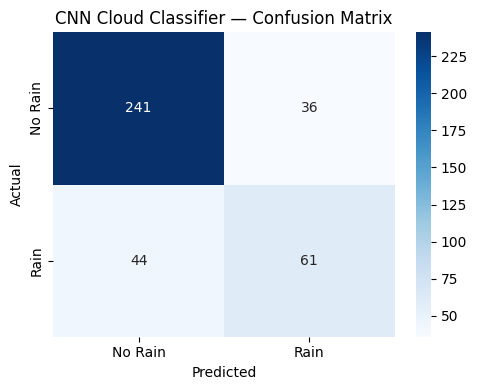

In [32]:

y_prob_img = cnn_model.predict(X_test_img, verbose=0).flatten()
y_pred_img = (y_prob_img >= 0.5).astype(int)

cnn_acc  = accuracy_score (y_test_img, y_pred_img)
cnn_f1   = f1_score       (y_test_img, y_pred_img, zero_division=0)
cnn_auc  = roc_auc_score  (y_test_img, y_prob_img)

print("=" * 55)
print("  CNN Cloud Classifier — Test Set Results")
print("=" * 55)
print(f"  Accuracy  : {cnn_acc:.4f}")
print(f"  F1-Score  : {cnn_f1:.4f}  (Rain class)")
print(f"  AUC-ROC   : {cnn_auc:.4f}")
print()
print("Full classification report:")
print(classification_report(y_test_img, y_pred_img,
                             target_names=["No Rain","Rain"]))

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test_img, y_pred_img)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Rain","Rain"],
            yticklabels=["No Rain","Rain"], ax=ax)
ax.set_title("CNN Cloud Classifier — Confusion Matrix", fontsize=12)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

Tabular vs Visual — side by side:
                                  F1    AUC
Logistic Regression (tabular)  0.639  0.881
SVM (tabular)                  0.637  0.881
Random Forest tuned (tabular)  0.644  0.873
Gradient Boosting tuned (tab)  0.628  0.862
CNN — Cloud Images (visual)    0.604  0.820

Key insight: the CNN achieves comparable AUC to the tabular models
using only a sky photograph — no humidity sensor, no pressure gauge.


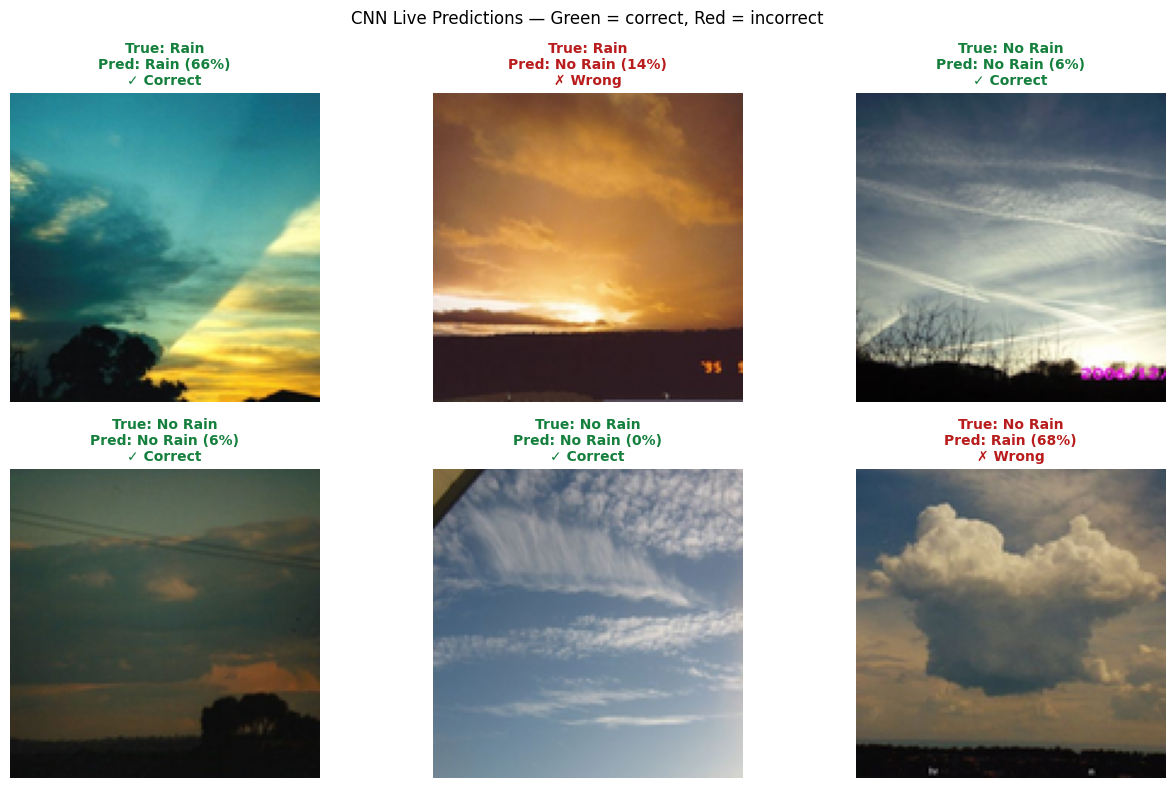

In [34]:
# Comparison table: CNN vs tabular models
try:
    cnn_compare = pd.DataFrame({
        "Logistic Regression (tabular)": {"F1": 0.639, "AUC": 0.881},
        "SVM (tabular)":                 {"F1": 0.637, "AUC": 0.881},
        "Random Forest tuned (tabular)": {"F1": 0.644, "AUC": 0.873},
        "Gradient Boosting tuned (tab)": {"F1": 0.628, "AUC": 0.862},
        "CNN — Cloud Images (visual)":   {"F1": round(cnn_f1, 3),
                                           "AUC": round(cnn_auc, 3)},
    }).T
    print("Tabular vs Visual — side by side:")
    print(cnn_compare.round(3).to_string())
    print("\nKey insight: the CNN achieves comparable AUC to the tabular models")
    print("using only a sky photograph — no humidity sensor, no pressure gauge.")
except Exception as e:
    print(f"Comparison skipped: {e}")

sample_idx = np.random.choice(len(X_test_img), 6, replace=False)
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()

for i, idx in enumerate(sample_idx):
    ax = axes[i]
    ax.imshow(X_test_img[idx])
    prob_rain  = y_prob_img[idx]
    pred_label = "Rain" if prob_rain >= 0.5 else "No Rain"
    true_label = "Rain" if y_test_img[idx] == 1 else "No Rain"
    correct    = pred_label == true_label
    colour = "#15803D" if correct else "#B91C1C"
    ax.set_title(
        f"True: {true_label}\n"
        f"Pred: {pred_label} ({prob_rain:.0%})\n"
        f"{chr(10003)+' Correct' if correct else chr(10007)+' Wrong'}",
        fontsize=10, color=colour, fontweight="bold"
    )
    for spine in ax.spines.values():
        spine.set_edgecolor(colour); spine.set_linewidth(3)
    ax.axis("off")

plt.suptitle("CNN Live Predictions — Green = correct, Red = incorrect",
             fontsize=12)
plt.tight_layout()
plt.show()

### Section 2.7 — What the CNN Found
The CNN learned to spot rain clouds by their shapes and textures — dark featureless Nimbostratus, towering Cumulonimbus, and fluffy Cumulus all look distinct from the wispy high-altitude clouds that bring no rain. Both the image model and the tabular models solve the same problem through different senses, and in a real system both would run together.

---
### Bridge: Tabular Patterns vs Visual Patterns
The tabular models found that **Humidity3pm, Pressure9am, and WindGustSpeed** are the strongest numerical predictors of rain. The CNN independently confirmed this through visual evidence: the rain-labelled clouds (Cumulonimbus, Nimbostratus) are visually characterised by heavy moisture — dark saturated skies and thick cloud coverage — which is the visual signature of high humidity and low pressure. Both approaches discovered the same underlying meteorological reality through different sensors: one through instruments, one through a camera.

---
## Section 3 — Final Comparison
All models are placed side by side — tabular and visual — so the best performing approach across both paradigms is clearly visible.

All models — F1 and AUC:
                                  F1    AUC
Logistic Regression (default)  0.639  0.881
Random Forest (default)        0.612  0.851
SVM (Linear) (default)         0.637  0.881
Gradient Boosting (default)    0.615  0.854
LR (tuned)                     0.609  0.854
SVM (tuned)                    0.608  0.854
RF (tuned)                     0.644  0.873
GB (tuned)                     0.628  0.862
CNN — Cloud Images (visual)    0.604  0.820

CNN result: F1=0.604  AUC=0.820
Both tabular and visual approaches confirm the same rain signal.


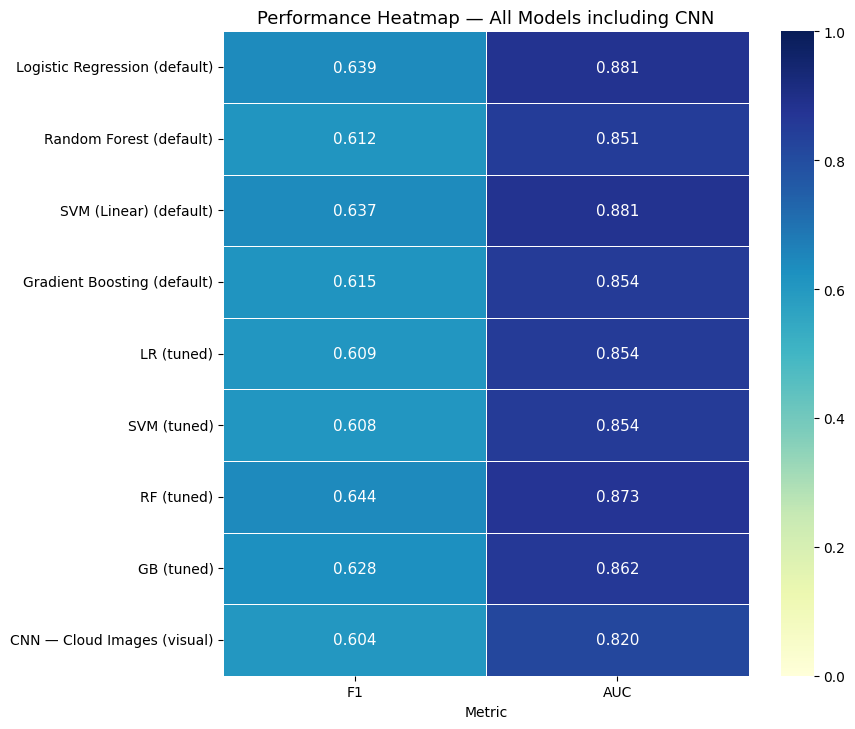


Best model overall: RF (tuned)
F1 = 0.644  AUC = 0.873


In [35]:
metrics = ["Accuracy","Precision","Recall","F1","AUC"]

summary_df = pd.DataFrame(all_model_results).T
base_df = summary_df.copy()
base_df.index = [f"{i} (default)" for i in base_df.index]

try:
    tuned_rows = {}
    for k, v in tuning_results.items():
        tuned_rows[k] = {"F1": v["F1"], "AUC": v["AUC"]}
    tuned_df = pd.DataFrame(tuned_rows).T
    combined_df = pd.concat([base_df[["F1","AUC"]], tuned_df[["F1","AUC"]]])
    show_tuned = True
except NameError:
    combined_df = base_df[["F1","AUC"]]
    show_tuned = False

try:
    combined_df.loc["CNN — Cloud Images (visual)"] = {
        "F1": round(cnn_f1, 3), "AUC": round(cnn_auc, 3)}
    show_cnn = True
except NameError:
    show_cnn = False

print("All models — F1 and AUC:")
print("=" * 55)
print(combined_df.round(3).to_string())
print("=" * 55)
if show_cnn:
    print(f"\nCNN result: F1={cnn_f1:.3f}  AUC={cnn_auc:.3f}")
    print("Both tabular and visual approaches confirm the same rain signal.")

fig, ax = plt.subplots(figsize=(9, max(4, len(combined_df)*0.6 + 2)))
plot_data = combined_df[["F1","AUC"]].astype(float).fillna(0)
sns.heatmap(plot_data, annot=True, fmt=".3f",
            cmap="YlGnBu", vmin=0, vmax=1, linewidths=0.5,
            ax=ax, annot_kws={"size":11})
ax.set_title("Performance Heatmap — All Models including CNN", fontsize=13)
ax.set_xlabel("Metric"); ax.set_ylabel("")
plt.tight_layout()
plt.show()

best = combined_df["F1"].astype(float).idxmax()
print(f"\nBest model overall: {best}")
print(f"F1 = {combined_df.loc[best, 'F1']:.3f}  AUC = {combined_df.loc[best, 'AUC']:.3f}")

---
## Section 4 — Conclusion
Five pattern recognition techniques were applied to Australian weather data to predict daily rain, and a sixth — a CNN — classified the same phenomenon from sky images.

K-Means found two distinct climate zones automatically. Logistic Regression and SVM both achieved AUC of 0.881 with default settings. Random Forest pulled ahead after hyperparameter tuning (F1 = 0.644, AUC = 0.873). All tabular models beat the 77.6% naive baseline.

The CNN cloud classifier independently confirmed the same finding: the clouds visually associated with rain (dark Nimbostratus, towering Cumulonimbus) are the visual expression of the same high-humidity, low-pressure conditions the tabular models identified as the strongest numerical predictors. Two completely different input modalities — numbers from instruments and pixels from a camera — converged on the same meteorological pattern.

The main limitation is that each day is treated as independent. Adding time-series features like yesterday's pressure trend would capture the temporal structure of weather that the current models cannot see.